# 地下水＋非都市人口密度14変数モデル：実行結果レポート

このNotebookは、完了済みのSpatial OOF・SHAP・Permutation importanceの保存結果を読み込み、出力セル付きで確認するためのレポートです。重いモデル学習は再実行しません。

完全な分析コードは `cropland_soil_group_wetland_excluded_groundwater_rural_population_oof_shap_target2020.ipynb` にあります。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path('/work/tsuda/GAEZ')
RESULT_DIR = ROOT / 'CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_target2020'
POP_DIR = ROOT / 'PopulationData/rural_population_2020_5min'
assert RESULT_DIR.is_dir(), RESULT_DIR
print('Result directory:', RESULT_DIR)
print('Result files:', sum(path.is_file() for path in RESULT_DIR.rglob('*')))

Result directory: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_target2020
Result files: 85


## 非都市人口密度の計算確認

モデル入力は、各5分グリッドの非都市人口を同じグリッドの面積（km²）で割り、`log1p`変換した値です。

In [2]:
rural_population = np.load(POP_DIR / 'rural_population_2020_5min.npy', mmap_mode='r')
cell_area_km2 = np.load(POP_DIR / 'cell_area_km2_5min.npy', mmap_mode='r')
saved_density = np.load(POP_DIR / 'rural_population_density_2020_5min.npy', mmap_mode='r')
calculated_density = np.divide(
    rural_population, cell_area_km2,
    out=np.zeros(rural_population.shape, dtype=np.float32),
    where=np.asarray(cell_area_km2) > 0,
)
max_abs_difference = float(np.nanmax(np.abs(calculated_density - saved_density)))
display(pd.DataFrame({
    'item': ['population array shape', 'area array shape', 'density unit', 'model variable', 'maximum difference from saved density'],
    'value': [str(rural_population.shape), str(cell_area_km2.shape), 'persons / km²', 'log1p(rural_population / cell_area_km2)', max_abs_difference],
}))

,item,value
0,population array shape,"(2160, 4320)"
1,area array shape,"(2160, 4320)"
2,density unit,persons / km²
3,model variable,log1p(rural_population / cell_area_km2)
4,maximum difference from saved density,0.000488


## 13変数モデルと14変数モデルのSpatial OOF比較

,weighting,n_cells,old_13_r2,new_14_r2,r2_change_new_minus_old,old_13_rmse,new_14_rmse,rmse_improvement_pct,old_13_mae,new_14_mae,mae_improvement_pct
0,unweighted,240000,0.635750,0.679653,0.043903,0.133583,0.125274,6.219880,0.075471,0.069990,7.262917
1,area_weighted,240000,0.622878,0.672211,0.049334,0.127854,0.119198,6.769984,0.070017,0.064255,8.229013


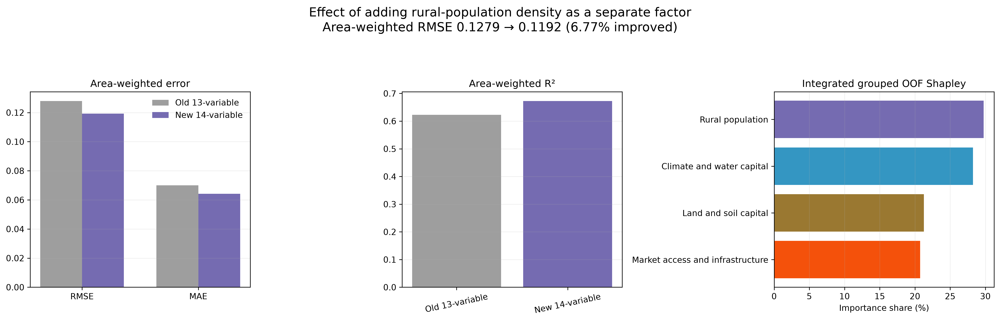

In [3]:
comparison = pd.read_csv(RESULT_DIR / 'rural_population_14feature_vs_13feature_metrics.csv')
display(comparison)
display(Image(filename=str(RESULT_DIR / 'rural_population_14feature_evaluation_summary.png'), width=1200))

## 統合OOF Shapley重要度

### Factor group

,group_code,group,mean_abs_shapley,mean_signed_shapley,importance_share_pct
0,rural_population,Rural population,0.046488,-0.000735,29.750748
1,climate_water,Climate and water capital,0.044136,-0.000509,28.245895
2,land_soil,Land and soil capital,0.033238,-0.000426,21.271290
3,market_infrastructure,Market access and infrastructure,0.032395,-0.000022,20.732067


### Individual feature

,feature,group_code,group,mean_abs_shapley,mean_signed_shapley,importance_share_pct
0,log_rural_population_density_2020,rural_population,Rural population,0.047299,-0.000684,22.735405
1,log_city_time_20k_min,market_infrastructure,Market access and infrastructure,0.028948,-0.000140,13.914708
2,wx_50km_rainfed_calorie_top5_raw,climate_water,Climate and water capital,0.022790,0.000078,10.954757
3,soil_group_class,land_soil,Land and soil capital,0.018565,-0.000317,8.923973
4,exclusion_class,land_soil,Land and soil capital,0.015357,-0.000108,7.381625
5,irrigation_calorie_gain_top5_raw,climate_water,Climate and water capital,0.013993,-0.000253,6.726129
6,rainfed_calorie_top5_raw,climate_water,Climate and water capital,0.013163,-0.000096,6.327306
7,log_fan_water_table_depth_m,climate_water,Climate and water capital,0.010301,-0.000138,4.951407
8,slope,land_soil,Land and soil capital,0.009664,0.000034,4.645117
9,log_port_time_any_min,market_infrastructure,Market access and infrastructure,0.006973,0.000221,3.351890


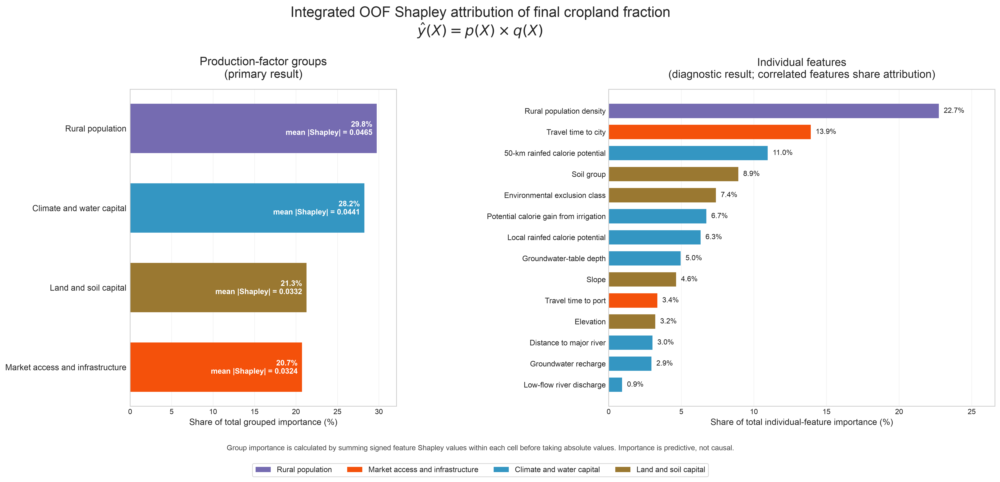

In [4]:
archive = RESULT_DIR / 'integrated_shapley_archive_bg32_perm32'
group_shap = pd.read_csv(archive / 'integrated_group_shapley_global_summary.csv')
feature_shap = pd.read_csv(archive / 'integrated_feature_shapley_global_summary.csv')
display(Markdown('### Factor group'))
display(group_shap)
display(Markdown('### Individual feature'))
display(feature_shap)
display(Image(filename=str(RESULT_DIR / 'integrated_final_shapley_summary_bg32_perm32_fixed.png'), width=1200))

## Spatial OOF permutation importance

### Individual feature

,rank,model,feature,baseline_mse,permuted_mse,delta_mse,percent_increase_mse,mean_percent_increase_mse,std_percent_increase_mse,n_folds,n_repeats
0,1,soil_group_wetland_excluded_groundwater_rural_...,log_rural_population_density_2020,0.014208,0.027963,0.013755,96.810894,98.853355,35.490329,5,10
1,2,soil_group_wetland_excluded_groundwater_rural_...,log_city_time_20k_min,0.014208,0.021914,0.007706,54.232995,54.584535,12.023991,5,10
2,3,soil_group_wetland_excluded_groundwater_rural_...,soil_group_class,0.014208,0.018896,0.004688,32.996034,33.116398,6.408649,5,10
3,4,soil_group_wetland_excluded_groundwater_rural_...,wx_50km_rainfed_calorie_top5_raw,0.014208,0.017869,0.003661,25.764679,25.810902,5.678854,5,10
4,5,soil_group_wetland_excluded_groundwater_rural_...,irrigation_calorie_gain_top5_raw,0.014208,0.016195,0.001986,13.980143,14.010686,6.465220,5,10
5,6,soil_group_wetland_excluded_groundwater_rural_...,exclusion_class,0.014208,0.016175,0.001967,13.845624,13.865284,1.252310,5,10
6,7,soil_group_wetland_excluded_groundwater_rural_...,log_fan_water_table_depth_m,0.014208,0.015552,0.001344,9.459141,9.592525,3.222608,5,10
7,8,soil_group_wetland_excluded_groundwater_rural_...,log_port_time_any_min,0.014208,0.015539,0.001331,9.366895,9.357629,2.764087,5,10
8,9,soil_group_wetland_excluded_groundwater_rural_...,slope,0.014208,0.015528,0.001320,9.291456,9.386320,3.240770,5,10
9,10,soil_group_wetland_excluded_groundwater_rural_...,rainfed_calorie_top5_raw,0.014208,0.015406,0.001198,8.428766,8.681596,4.156782,5,10


### Factor group

,rank,model,group,baseline_mse,permuted_mse,delta_mse,percent_increase_mse,mean_percent_increase_mse,std_percent_increase_mse,n_folds,n_repeats,features
0,1,soil_group_wetland_excluded_groundwater_rural_...,Rural population,0.014208,0.027939,0.013731,96.637966,98.690354,35.796019,5,10,log_rural_population_density_2020
1,2,soil_group_wetland_excluded_groundwater_rural_...,Climate and water capital,0.014208,0.027237,0.013029,91.697829,92.847228,22.006203,5,10,"rainfed_calorie_top5_raw, irrigation_calorie_g..."
2,3,soil_group_wetland_excluded_groundwater_rural_...,Land and soil capital,0.014208,0.024719,0.010511,73.975349,74.500942,14.949409,5,10,"elevation_m, slope, exclusion_class, soil_grou..."
3,4,soil_group_wetland_excluded_groundwater_rural_...,Market access and infrastructure,0.014208,0.023539,0.009331,65.670615,66.182714,14.173183,5,10,"log_city_time_20k_min, log_port_time_any_min"


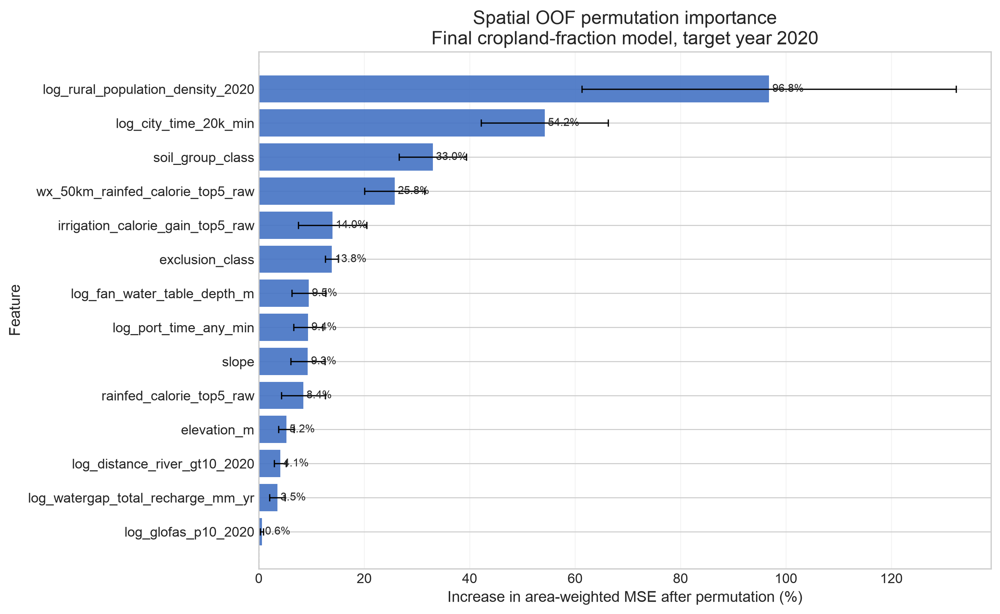

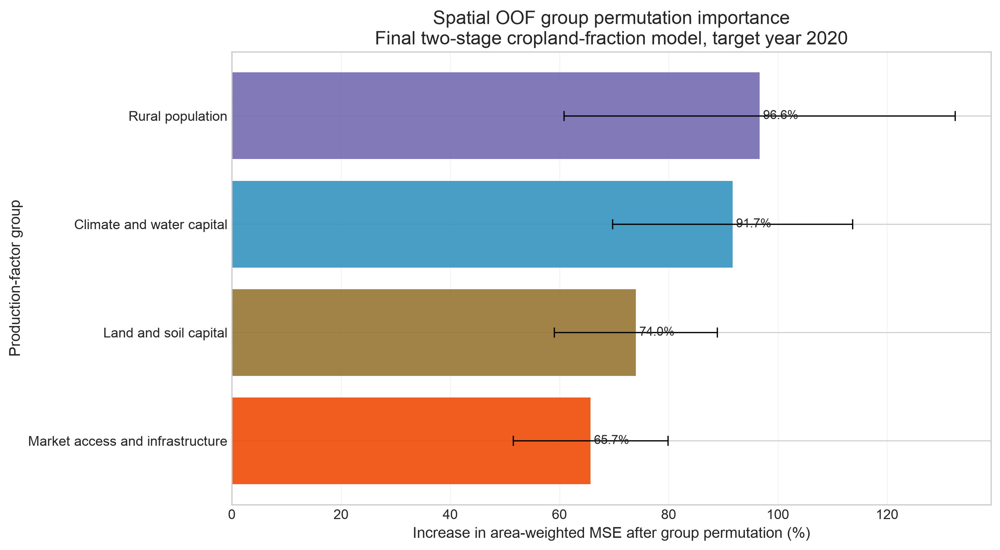

In [5]:
feature_perm_path = RESULT_DIR / 'permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_spatial_oof_permutation_importance.csv'
group_perm_path = RESULT_DIR / 'group_permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_spatial_oof_group_permutation_importance.csv'
display(Markdown('### Individual feature'))
display(pd.read_csv(feature_perm_path))
display(Markdown('### Factor group'))
display(pd.read_csv(group_perm_path))
display(Image(filename=str(feature_perm_path.with_suffix('.png')), width=1100))
display(Image(filename=str(group_perm_path.with_suffix('.png')), width=1100))

## 空間分布とSHAP図

### Spatial OOF diagnostics

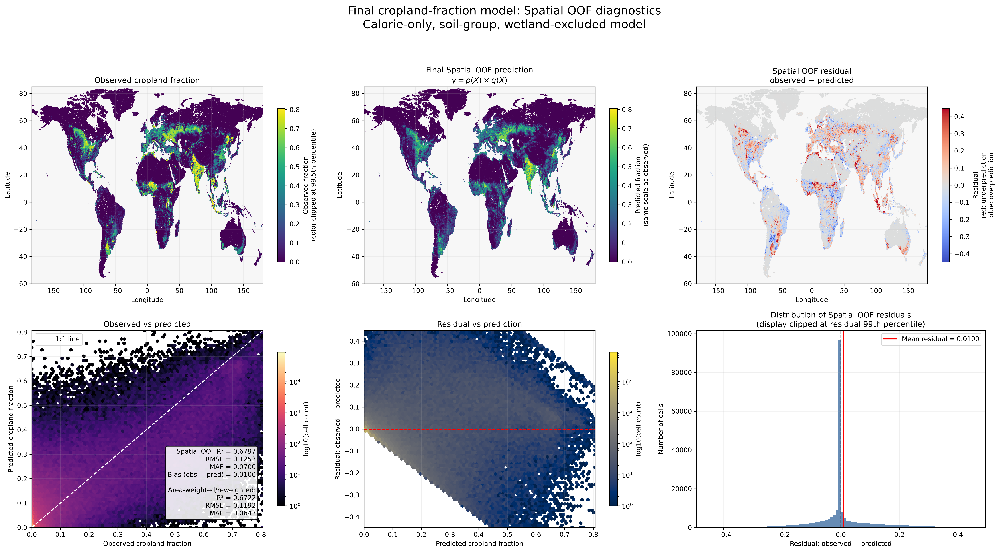

### Dominant factor map

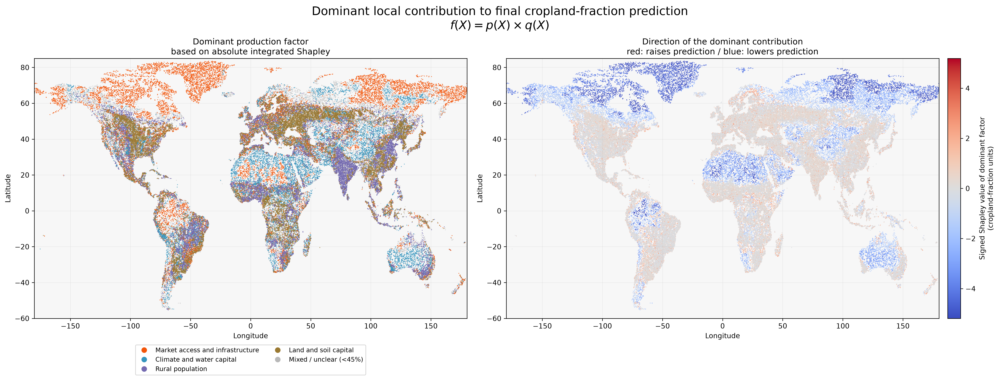

### Integrated OOF SHAP beeswarm

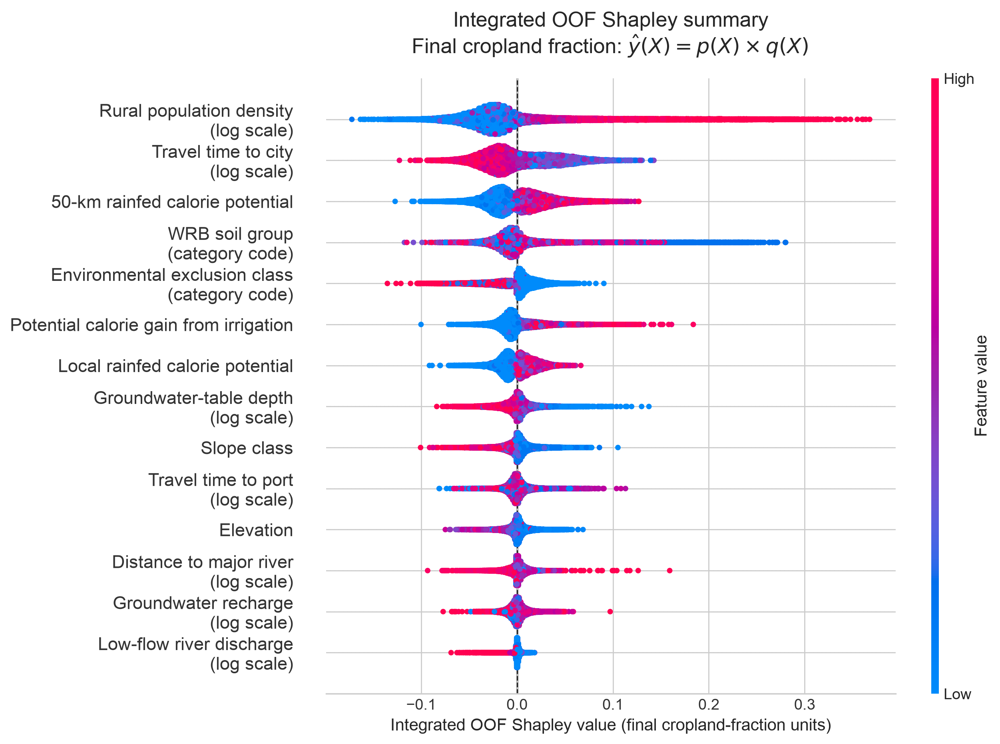

In [6]:
for title, filename in [
    ('Spatial OOF diagnostics', 'final_spatial_oof_model_diagnostics.png'),
    ('Dominant factor map', 'final_cropland_dominant_factor_map.png'),
    ('Integrated OOF SHAP beeswarm', 'saved_oof_shap_beeswarm/integrated_final_fraction_oof_shap_beeswarm.png'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(RESULT_DIR / filename), width=1200))

## 実行マニフェストと保存ファイル

In [7]:
manifest = json.loads((RESULT_DIR / 'groundwater_rural_population_14feature_run_manifest.json').read_text())
display(manifest)
print((RESULT_DIR / 'result_file_index.txt').read_text())

{'notebook': '/work/tsuda/GAEZ/cropland_soil_group_wetland_excluded_groundwater_rural_population_oof_shap_target2020.ipynb',
 'output_directory': '/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_target2020',
 'target_year': 2020,
 'n_analysis_rows': 240000,
 'n_features': 14,
 'features': ['elevation_m',
  'slope',
  'exclusion_class',
  'log_city_time_20k_min',
  'log_port_time_any_min',
  'rainfed_calorie_top5_raw',
  'irrigation_calorie_gain_top5_raw',
  'wx_50km_rainfed_calorie_top5_raw',
  'log_distance_river_gt10_2020',
  'log_glofas_p10_2020',
  'soil_group_class',
  'log_fan_water_table_depth_m',
  'log_watergap_total_recharge_mm_yr',
  'log_rural_population_density_2020'],
 'final_model': 'soil_group_wetland_excluded_groundwater_rural_population',
 'spatial_oof_folds': 5,
 'rural_population_feature': 'log_rural_population_density_2020',
 'rural_population_definition': '2020 rural persons per cell divided by cell area in km2, then l

README_results.md
factor_group_oof_shap_corrected.png
factor_group_oof_shap_old_vs_corrected.png
feature_shap_dependence/conditional_fraction_regressor_dependence_page_1.png
feature_shap_dependence/conditional_fraction_regressor_dependence_page_2.png
feature_shap_dependence/presence_classifier_dependence_page_1.png
feature_shap_dependence/presence_classifier_dependence_page_2.png
final_cropland_dominant_factor_map.png
final_spatial_oof_model_diagnostics.png
groundwater_rural_population_14feature_run_manifest.json
group_permutation_importance_final_oof/fold_results/fold_01_repeats_10_seed_20260917.csv
group_permutation_importance_final_oof/fold_results/fold_02_repeats_10_seed_20260917.csv
group_permutation_importance_final_oof/fold_results/fold_03_repeats_10_seed_20260917.csv
group_permutation_importance_final_oof/fold_results/fold_04_repeats_10_seed_20260917.csv
group_permutation_importance_final_oof/fold_results/fold_05_repeats_10_seed_20260917.csv
group_permutation_importance_final_o